# Global correction analysis

In [1]:
%load_ext autoreload
%load_ext usnm2p.skip_kernel_extension
%autoreload 2

### Imports

In [2]:
# External packages
import os
import jupyter_slack
import datetime
import itertools
import matplotlib.colors as mcolors
from statannotations.Annotator import Annotator
import diptest
from scipy.stats import ttest_1samp, shapiro

# Internal modules
from usnm2p.logger import logger
from usnm2p.constants import *
from usnm2p.utils import *
from usnm2p.indexers import *
from usnm2p.fileops import *
from usnm2p.postpro import *
from usnm2p.plotters import *
from usnm2p.batchutils import *
from usnm2p.surrogates import generate_surrogate
from usnm2p.correctors import *
from usnm2p.parsers import extract_FOV_area, resolve_mouseline

# Figures dictionary
figs = {}

### Input datasets and main processing parameters

In [3]:
# Processing parameters
analysis_type = 'main'  # Analysis type
mouseline = 'sst'  # mouse line
layer = None  # cortical layer
slack_notify = False
global_corrections = [None, 'linreg_robust']
kalman_gain = KALMAN_GAIN  # gain of Kalman filter
neuropil_scaling_coeff = NEUROPIL_SCALING_COEFF  # scaling coefficient for neuropil subtraction
baseline_quantile = BASELINE_QUANTILE  # evaluation quantile for baseline computation
baseline_wquantile = BASELINE_WQUANTILE  # quantile filter window size (s) to compute fluorescence baseline
baseline_wsmoothing = BASELINE_WSMOOTHING  # gaussian filter window size (s) to smooth out fluorescence baseline
trial_aggfunc = TRIAL_AGGFUNC  # trial aggregation function
ykey_classification = YKEY_CLASSIFICATION  # Reference variable for response classification
directional = DIRECTIONAL_DETECTION  # whether to look for directional (i.e. positive only) effect for response detection

### Derived parameters

In [4]:
# GCaMP channel key
gcamp_key = get_gcamp_key(mouseline)

# Get batch-related settings
input_dirs = {}
for global_correction in global_corrections:
    dataset_group_id, input_dir, figsdir, _ = get_batch_settings(
        analysis_type, mouseline, layer, global_correction, kalman_gain, neuropil_scaling_coeff,
        baseline_quantile, baseline_wquantile, baseline_wsmoothing,
        trial_aggfunc, ykey_classification, directional)
    input_dirs[global_correction] = input_dir
baseline_id = get_baseline_id(baseline_quantile, baseline_wquantile, baseline_wsmoothing)

# Figures suffix
figs_suffix = f'global_correction_analysis_{mouseline}'
 
# Get time stamp from notebook start
tstamp_start = datetime.datetime.now()
fmts = ['%Y-%m-%d', '%H:%M:%S']
# Log start process
s = f'{dataset_group_id} {analysis_type} analysis notebook started on {tstamp_start.strftime(fmts[0])} at {tstamp_start.strftime(fmts[1])}'
if slack_notify:
    jupyter_slack.notify_self(s)
logger.info(s)

 2026/06/24 11:11:33: assembling batch analysis settings...
 2026/06/24 11:11:33: assembling batch analysis settings...
 2026/06/24 11:11:33: sst main analysis notebook started on 2026-06-24 at 11:11:33


### Input summary table figure

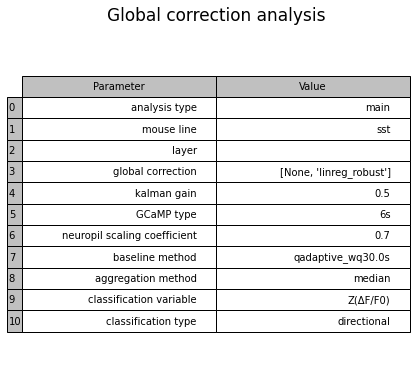

In [5]:
figs['dataset_info'] = plot_table({
    'analysis type': analysis_type,
    'mouse line': mouseline,
    'layer': layer,
    'global correction': global_corrections,
    'kalman gain': kalman_gain,
    'GCaMP type': gcamp_key,
    'neuropil scaling coefficient': neuropil_scaling_coeff,
    'baseline method': baseline_id,
    'aggregation method': trial_aggfunc.__name__,
    'classification variable': ykey_classification,
    'classification type': f"{'' if directional else 'non '}directional",
    }, title='Global correction analysis', aspect=1.5)

## Load & inspect initial data

### Load data

In [6]:
# Determine what to do in case of duplicate runs
on_duplicate_runs = 'drop_first'

datasets = [
    '20190510_mouse6_region2',
    '20190516_mouse8_region2',
]

# Load datasets
data = {}
for key, input_dir in input_dirs.items():
    logger.info(f'loading data from {input_dir}:')
    data['no correction' if key is None else key] = load_processed_datasets(
        input_dir, layer=layer,
        exclude_patterns=None,
        on_duplicate_runs=on_duplicate_runs,
        dataset_filter=datasets,
    )
logger.info('data successfully loaded.')

# Merge datasets into single dataframes with an additional column indicating the global correction method 
logger.info('merging datasets across global correction method...')
subkeys = list(data['no correction'].keys())
newdata = {}
for sk in subkeys:
    if isinstance(data['no correction'][sk], pd.DataFrame):
        newdata[sk] = pd.concat({k: data[k][sk] for k in data.keys()}, names=['global_correction'], axis=0)
    else:
        newdata[sk] = {k: data[k][sk] for k in data.keys()}
data = newdata

 2026/06/24 11:11:33: loading data from /gpfs/scratch/lemait01/data/usnm/processed/aggmedian_classzscore_directional/alpha0.7_qadaptive_wq30.0s/suite2p_fs_3.56_reg_tif_tau_1.25/kd_G0.5_V0.05_npad10/submap_0<-1_stim-1->stimeverytrial/main/sst:
 2026/06/24 11:11:33: gathering dataset IDs...
 2026/06/24 11:11:34: loading mouse-region data from 20190510_mouse6_region2.h5


 2026/06/24 11:11:34: loading mouse-region data from 20190516_mouse8_region2.h5
 2026/06/24 11:11:34: assembling data structures...
 2026/06/24 11:11:34: harmonizing run index by param across datasets
 2026/06/24 11:11:34: generating expanded conditions...
 2026/06/24 11:11:36: expanding "triagg_stats" condition to match "trialagg_timeseries" timeseries
 2026/06/24 11:11:36: expanding "stats" condition w/o. ['ROI'] dimensions to match "popagg_timeseries" timeseries
 2026/06/24 11:11:36: updating trialagg_timeseries run index
 2026/06/24 11:11:36: updating popagg_timeseries run index
 2026/06/24 11:11:36: updating stats run index
 2026/06/24 11:11:36: updating triagg_stats run index
 2026/06/24 11:11:36: sorting data structures index...
 2026/06/24 11:11:36: processing run IDs to uncover run sequences...
 2026/06/24 11:11:36: loading data from /gpfs/scratch/lemait01/data/usnm/processed/aggmedian_classzscore_directional/alpha0.7_qadaptive_wq30.0s/suite2p_fs_3.56_reg_tif_tau_1.25/kd_G0.5_

### Unpack data

In [7]:
# Unpack
trialagg_timeseries, popagg_timeseries, trialagg_stats, ext_stats, ROI_masks, map_ops = extract_from_batch_data(data)
if datasets is None:
    datasets = trialagg_timeseries.groupby(Label.DATASET).first().index.values.tolist()

# Extract number of frames per trial from timeseries multi-index
nframes_per_trial = popagg_timeseries.index.unique(level=Label.FRAME).max() + 1

# Assemble frame indexer object
tref = get_stim_onset_time(mouseline)
fps = get_singleton(trialagg_stats, Label.FPS)
tpost_short = 1.5  # s
fidx = FrameIndexer.from_time(tref, TPRE, tpost_short, 1 / fps, npertrial=nframes_per_trial)

 2026/06/24 11:11:39: extracting timeseries and stats from data...


### Plot ROI maps

 2026/06/24 11:11:40: plotting no correction FOVs
 2026/06/24 11:11:40: plotting cell maps...


100%|██████████| 2/2 [00:00<00:00,  2.81it/s]

 2026/06/24 11:11:40: plotting linreg_robust FOVs
 2026/06/24 11:11:40: plotting cell maps...



100%|██████████| 2/2 [00:00<00:00,  3.51it/s]


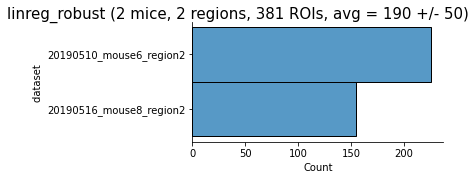

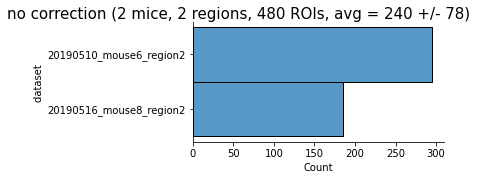

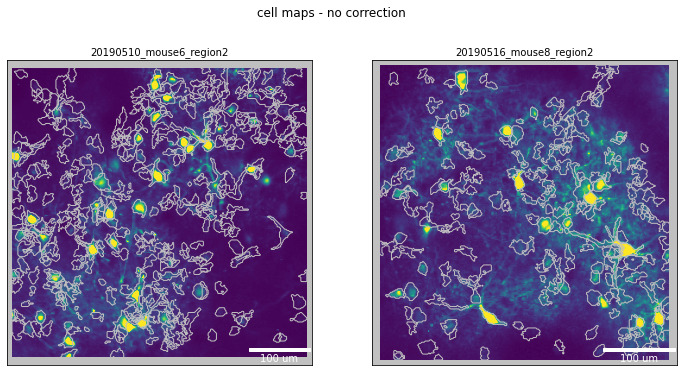

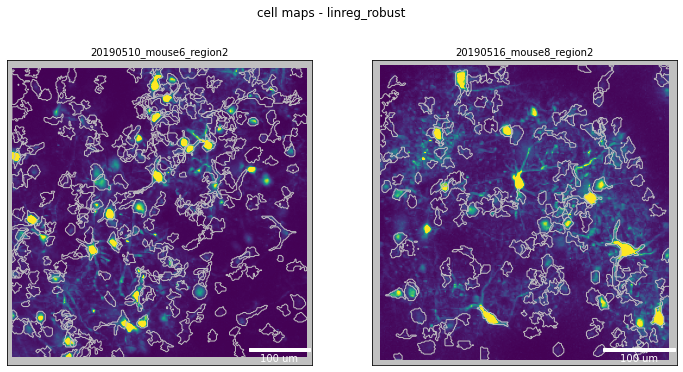

In [8]:
# Plot cell counts
for k, gstats in trialagg_stats.groupby('global_correction'):
    figs[f'cellcounts {k}'] = plot_cellcounts(gstats, hue=None, title=k)
    # figs[f'cellcounts {k}'].axes[0].set_xlim(0, 300)

# Plot cell maps
for k, v in map_ops.items():
    logger.info(f'plotting {k} FOVs')
    figs[f'cellmaps {k}'] = plot_fields_of_view(
        v, 
        refkey='max_proj',
        ROI_masks=ROI_masks.loc[k], 
        Fstats=trialagg_stats.loc[k], 
        mode='contour',
        qmax=.99,
        height=6,
        title=f'cell maps - {k}'
    )

### Plot response curves

 2026/06/24 11:11:42: adding ['fps' 'duration (s)' 'P (MPa)' 'DC (%)' 'I_SPTA (W/cm2)'] information to timeseries...


 2026/06/24 11:11:44: adding time info to table...
 2026/06/24 11:11:44: computing std of average ΔF/F0 signal for each condition...
 2026/06/24 11:11:44: normalizing ΔF/F0 signals for each condition...
 2026/06/24 11:11:45: offseting z-scored ΔF/F0 signals by their pre-stim value for each trial
 2026/06/24 11:11:46: plotting z-scored ΔF/F0 response traces...


Text(0.5, 1.05, 'sst - trial-averaged z-scored ΔF/F0 timeseries (ISPTA > 5.6 W/cm2)')

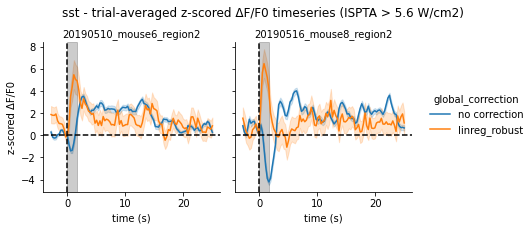

In [9]:
# Add critical stats columns to timeseries data
plt_data = get_plot_data(
    trialagg_timeseries,
    trialagg_stats,
    fidx
)

# Extract plot data for high dose conditions
highdose_ISPTA_thr = 5.6  # threshold ISPTA for high-dose runs selection
highdose_str = f'ISPTA > {highdose_ISPTA_thr} W/cm2'
stim_cond = plt_data[Label.ISPTA] > highdose_ISPTA_thr
plt_data = plt_data[stim_cond]

# Variable of interest
ykey = Label.DFF

# Compute std of average signal for each condition
logger.info(f'computing std of average {ykey} signal for each condition...')
yavgs_per_condition = (
    plt_data[ykey]
    .groupby(['global_correction', Label.FRAME])
    .mean()
    .groupby('global_correction')
    .std()
)

# Normalize signals for each condition
logger.info(f'normalizing {ykey} signals for each condition...')
norm_ykey = f'z-scored {ykey}'
plt_data[norm_ykey] = (
    plt_data[ykey]
    .groupby('global_correction')
    .transform(lambda x: x / yavgs_per_condition.loc[x.name])
)

# # Align signals by their pre-stim value for each trial
logger.info(f'offseting {norm_ykey} signals by their pre-stim value for each trial')
plt_data[norm_ykey] = (
    plt_data[norm_ykey]
    .groupby(excluded(plt_data.index, Label.FRAME))
    .transform(lambda x: x - x[fidx.iref])
)

# Plot average trace across datasets
logger.info(f'plotting {norm_ykey} response traces...')
title = f'{mouseline} - trial-averaged {norm_ykey} timeseries ({highdose_str})'
g = sns.relplot(
    kind='line',
    data=plt_data,
    x=Label.TIME,
    y=norm_ykey,
    errorbar='se',
    col=Label.DATASET,
    hue='global_correction',
    height=3,
)
g.refline(x=0, c='k', ls='--')
g.refline(y=0, c='k', ls='--')
g.set_titles(template='{col_name}')
figs[title] = g.fig
for ax in g.axes.flatten():
    ax.axvspan(0, fidx.npost / fps, color='k', alpha=.2)
figs[title].suptitle(title, y=1.05)

### Save figures

In [10]:
figs = {k: v for k, v in figs.items() if v is not None}
save_figs_book(figsdir, figs, suffix=figs_suffix)

 2026/06/24 11:11:49: saving figures in /gpfs/scratch/lemait01/data/usnm/figs/2026.06.24/figs_global_correction_analysis_sst.pdf:


100%|██████████| 6/6 [00:01<00:00,  5.46it/s]


### Notify upon completion

In [11]:
# Get time stamp from notebook completion
tstamp_end = datetime.datetime.now()

# Log completion process
s = f'{mouseline} batch notebook completed in {tstamp_end - tstamp_start} s'
if slack_notify:
    jupyter_slack.notify_self(s)
logger.info(s)

 2026/06/24 11:11:51: sst batch notebook completed in 0:00:18.009882 s
